In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import probplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import power_transform,PowerTransformer
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
df=pd.read_csv('/content/concrete_data.csv')

In [ ]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [ ]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
X=df.drop(columns=['Strength'])
Y=df['Strength']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [ ]:
lr=LinearRegression()
lr.fit(X_train,Y_train)
Y_pred=lr.predict(X_test)
r2_score(Y_test,Y_pred)

0.627553179231485

In [ ]:
np.mean(cross_val_score(lr,X,Y,scoring='r2',cv=5))

np.float64(0.46099404916628606)

/tmp/ipykernel_2111/1264425517.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col],ax=a1)
/tmp/ipykernel_2111/1264425517.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col],ax=a1)
/tmp/ipykernel_2111/1264425517.py:3: UserWarning: 

`distplot` is a deprecated function an

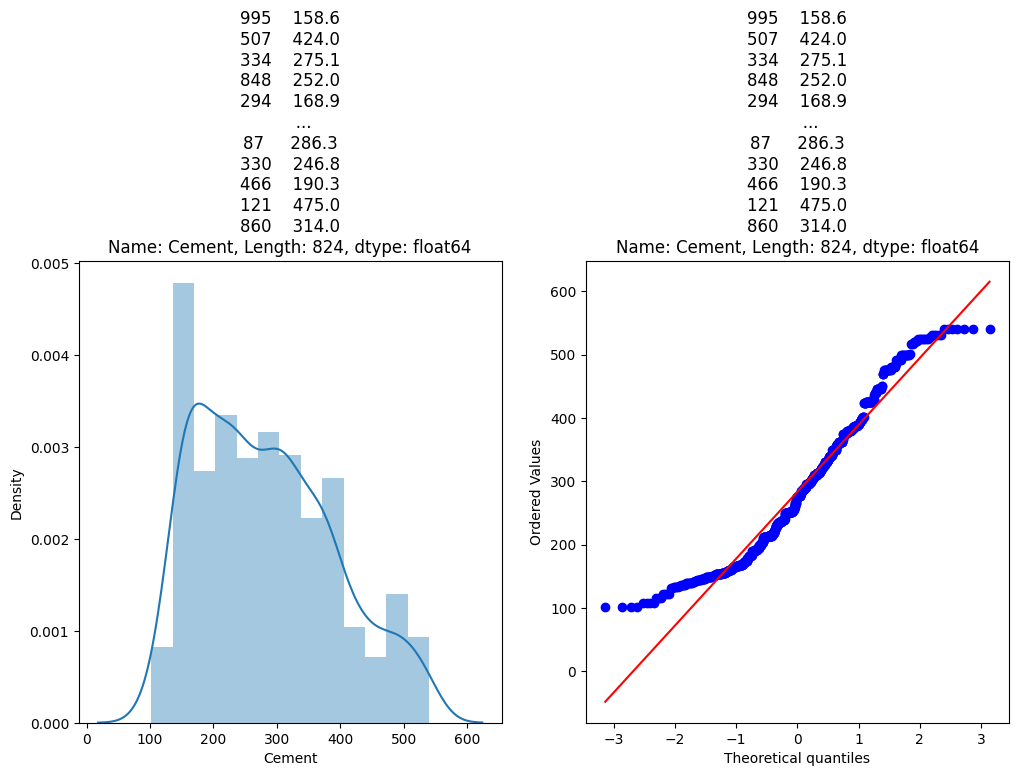

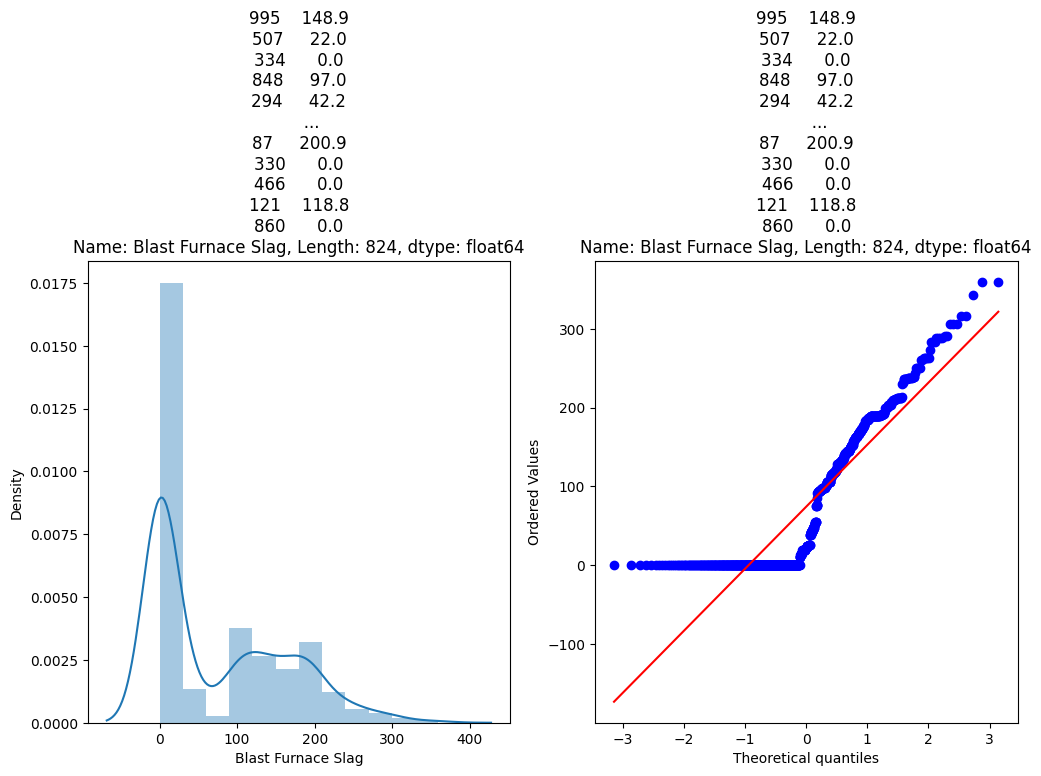

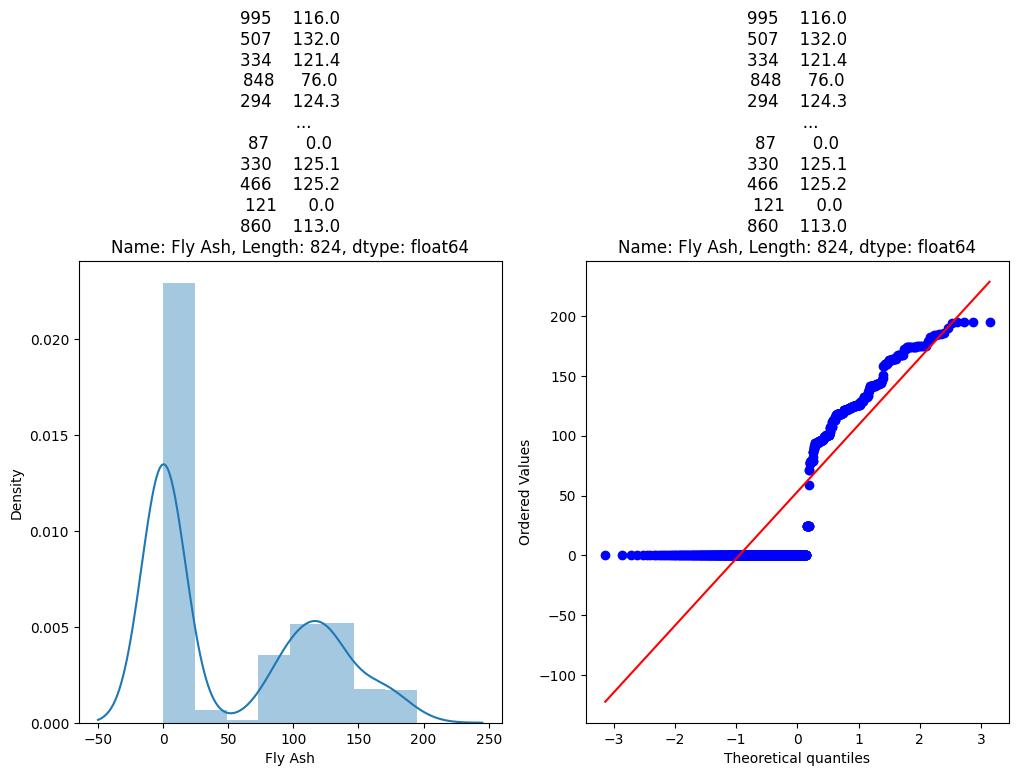

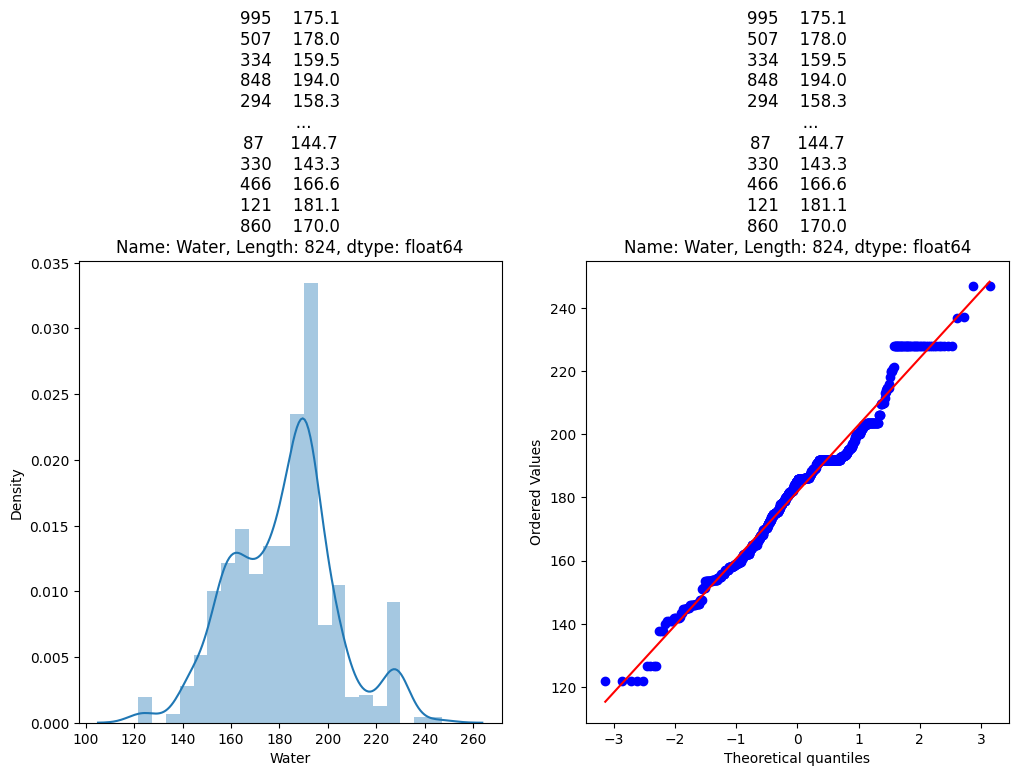

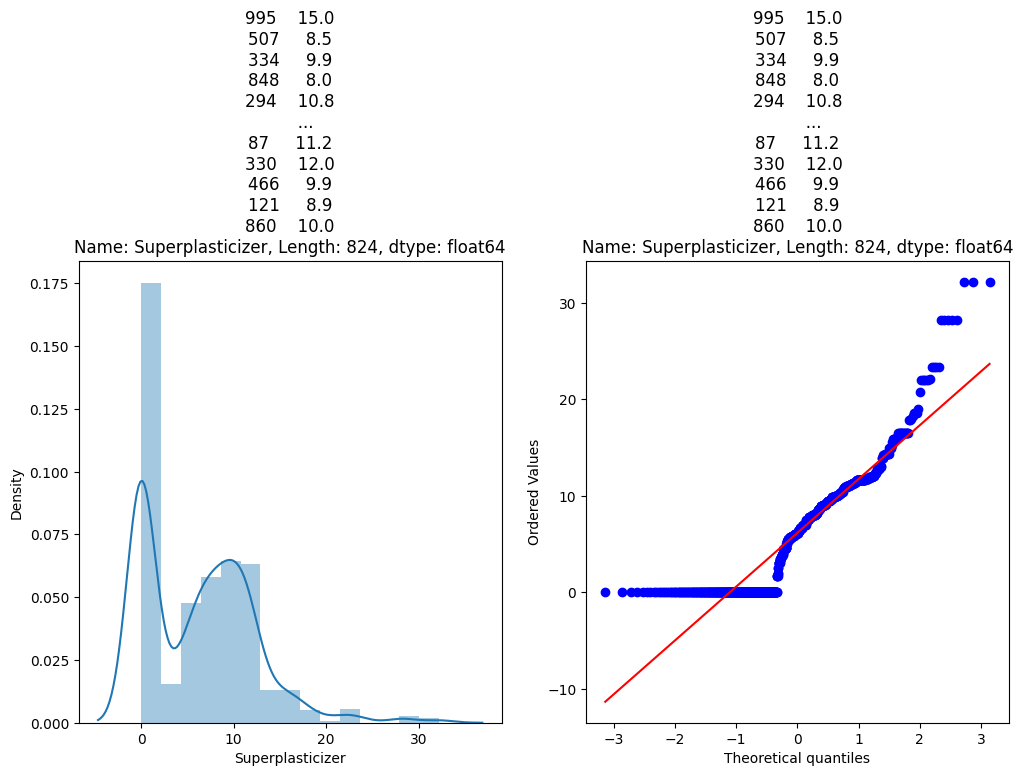

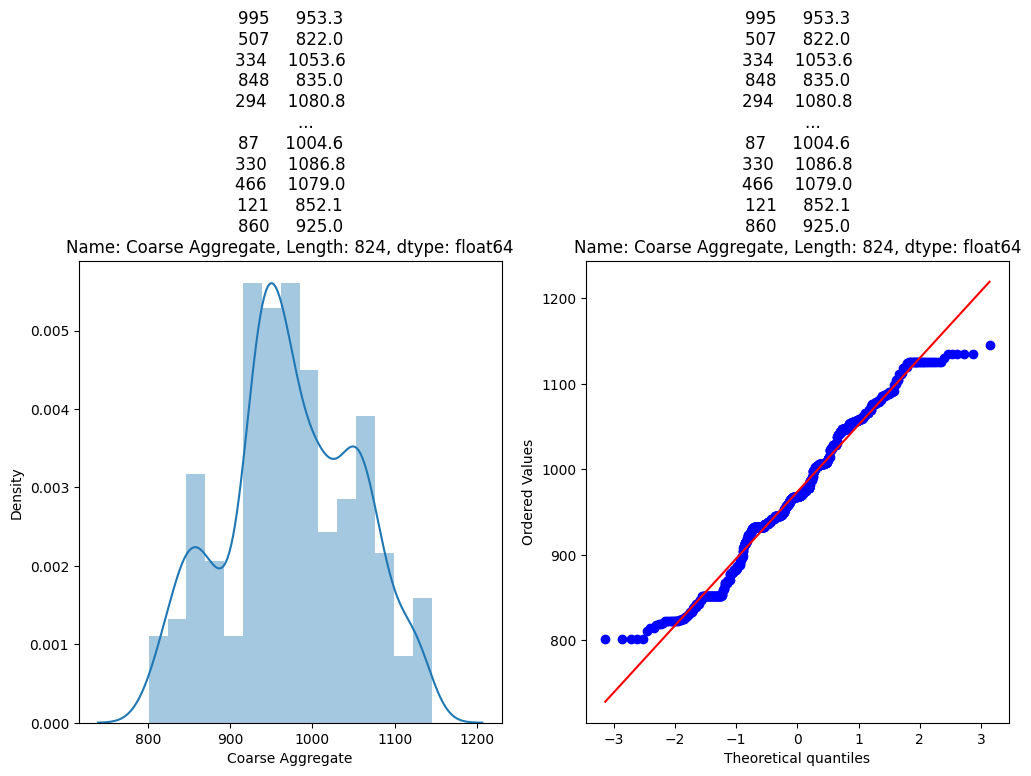

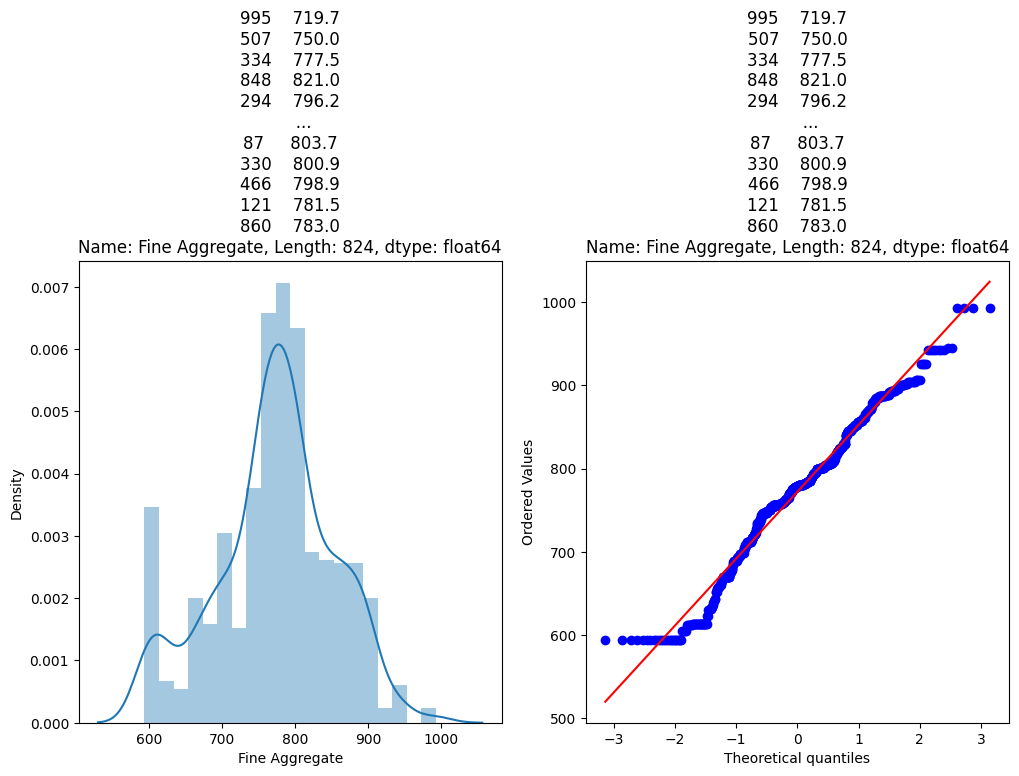

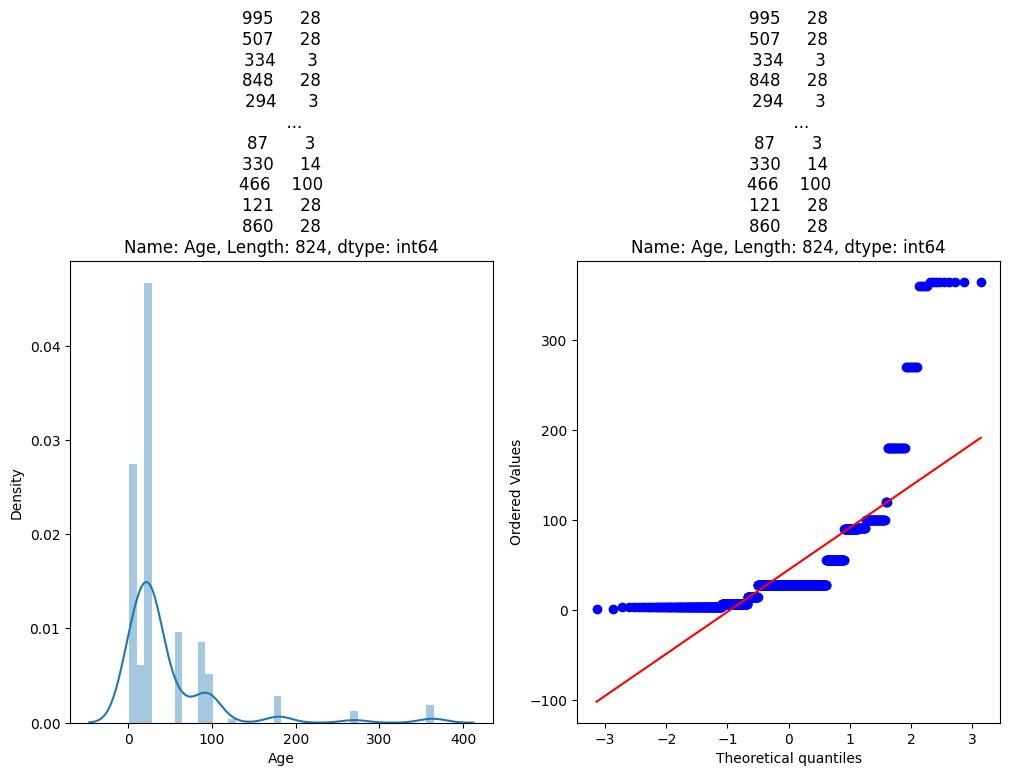

In [ ]:
for col in X_train.columns:
  fig,(a1,a2)=plt.subplots(ncols=2,figsize=(12,6))
  sns.distplot(X_train[col],ax=a1)
  a1.set_title(X_train[col])
  probplot(X_train[col],plot=a2)
  a2.set_title(X_train[col])
plt.show()

In [ ]:
pt=PowerTransformer(method='box-cox')
X_train_trf=pt.fit_transform(X_train+0.00000000001)
X_test_trf=pt.transform(X_test+0.00000000001)
pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.177025
1,Blast Furnace Slag,0.016421
2,Fly Ash,-0.023980
3,Water,0.772682
4,Superplasticizer,0.058914
5,Coarse Aggregate,1.129813
6,Fine Aggregate,1.782018
7,Age,0.066631


In [ ]:
lr.fit(X_train_trf,Y_train)
Y_pred2=lr.predict(X_test_trf)
r2_score(Y_test,Y_pred2)

0.8029517323841773

In [ ]:
X_trf=pt.fit_transform(X+0.00000000001)

In [ ]:
np.mean(cross_val_score(lr,X_trf,Y,scoring='r2'))

np.float64(0.6647104119595969)

/tmp/ipykernel_2111/3981000742.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_trf[col],ax=a1)
/tmp/ipykernel_2111/3981000742.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col],ax=a2)
/tmp/ipykernel_2111/3981000742.py:4: UserWarning: 

`distplot` is a deprecated functio

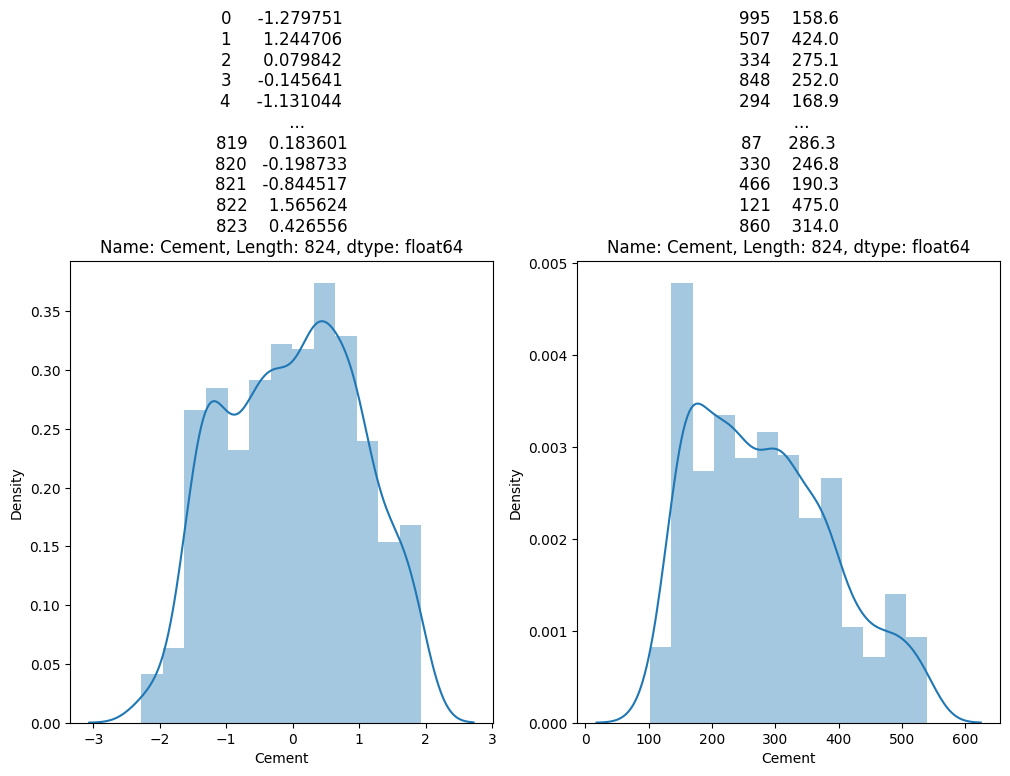

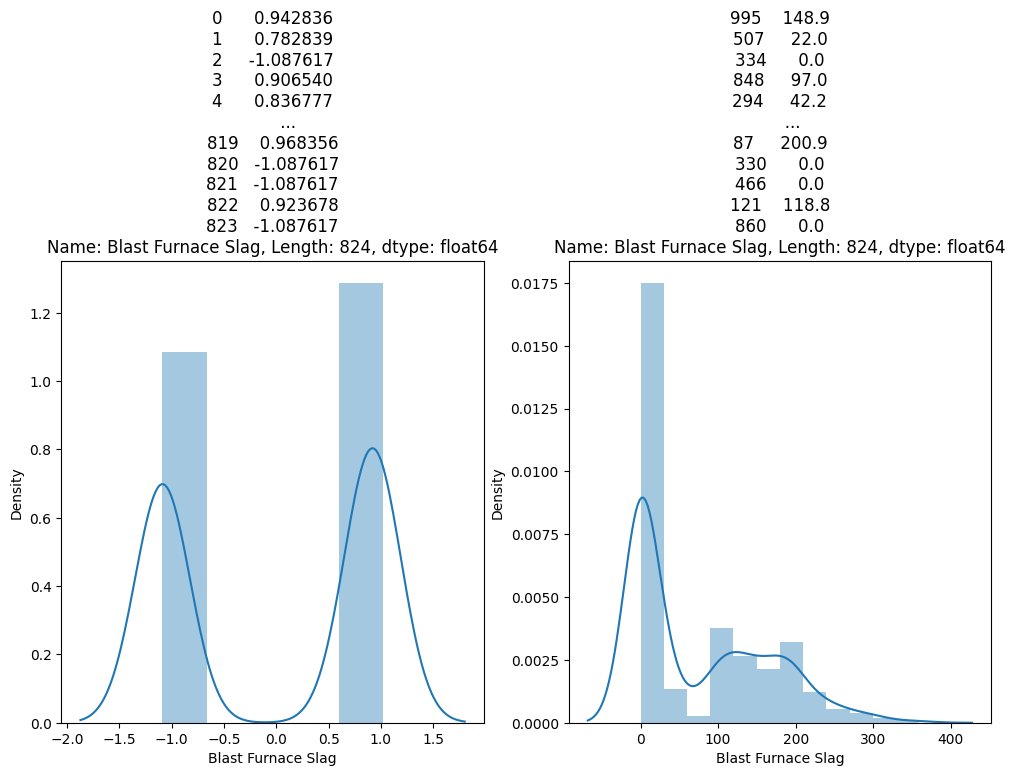

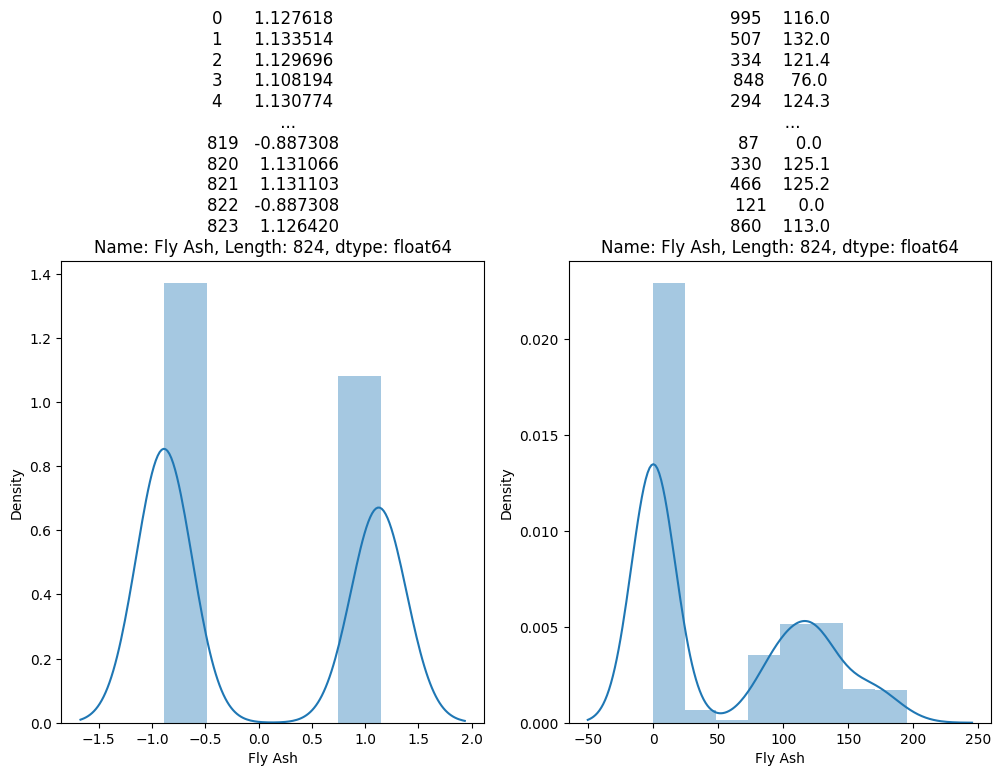

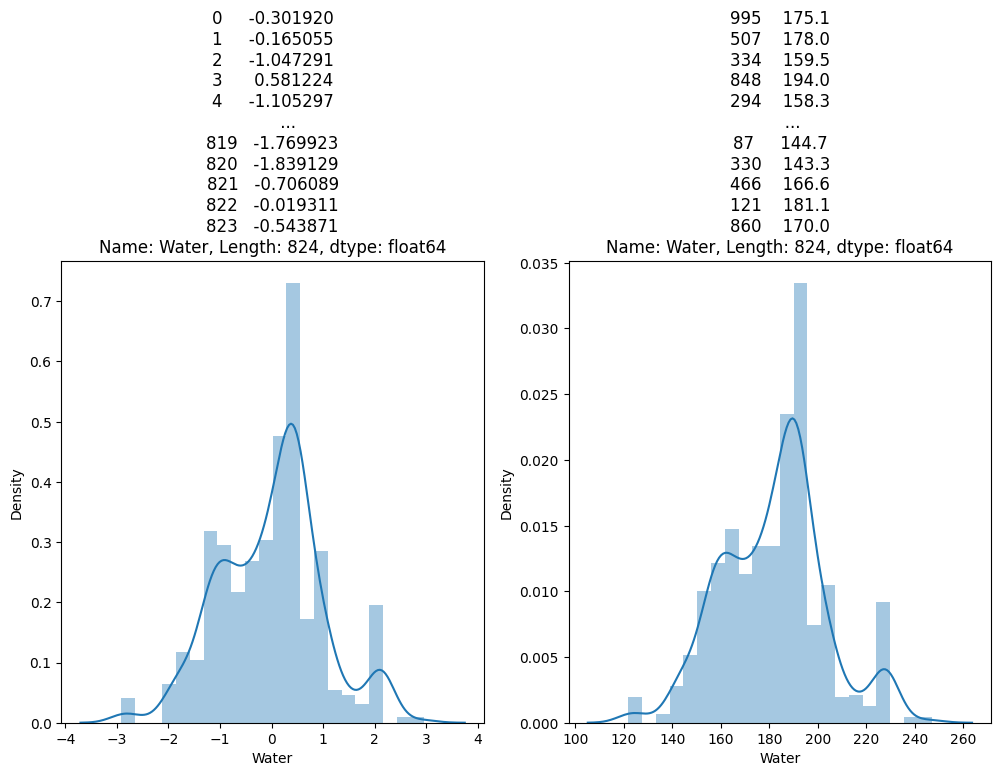

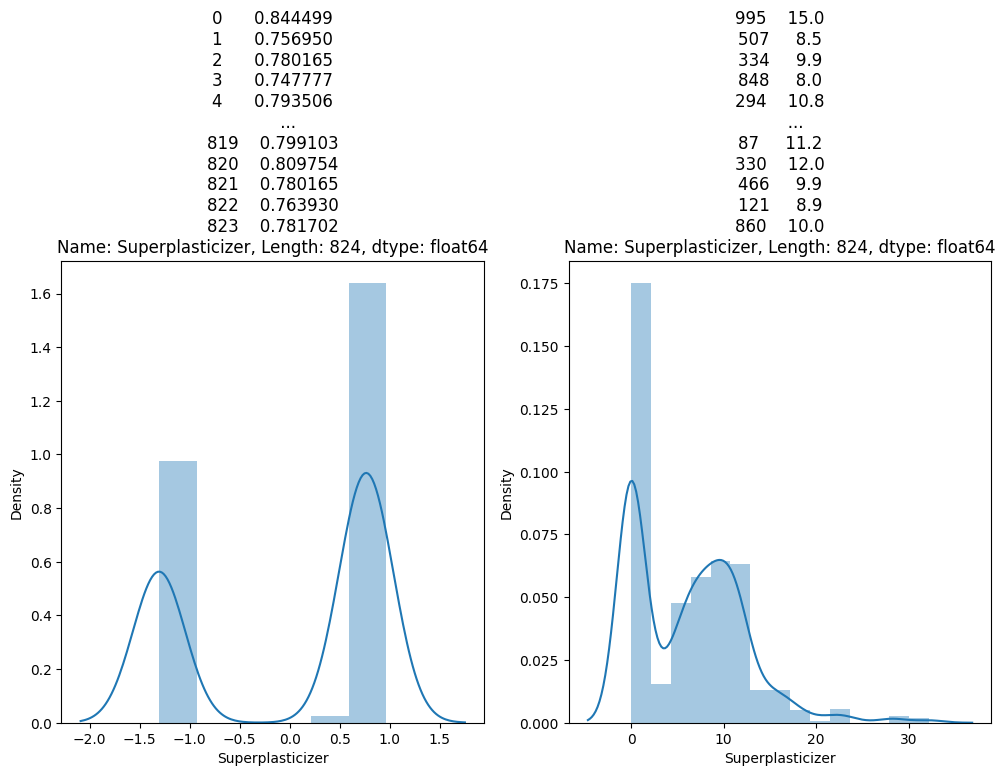

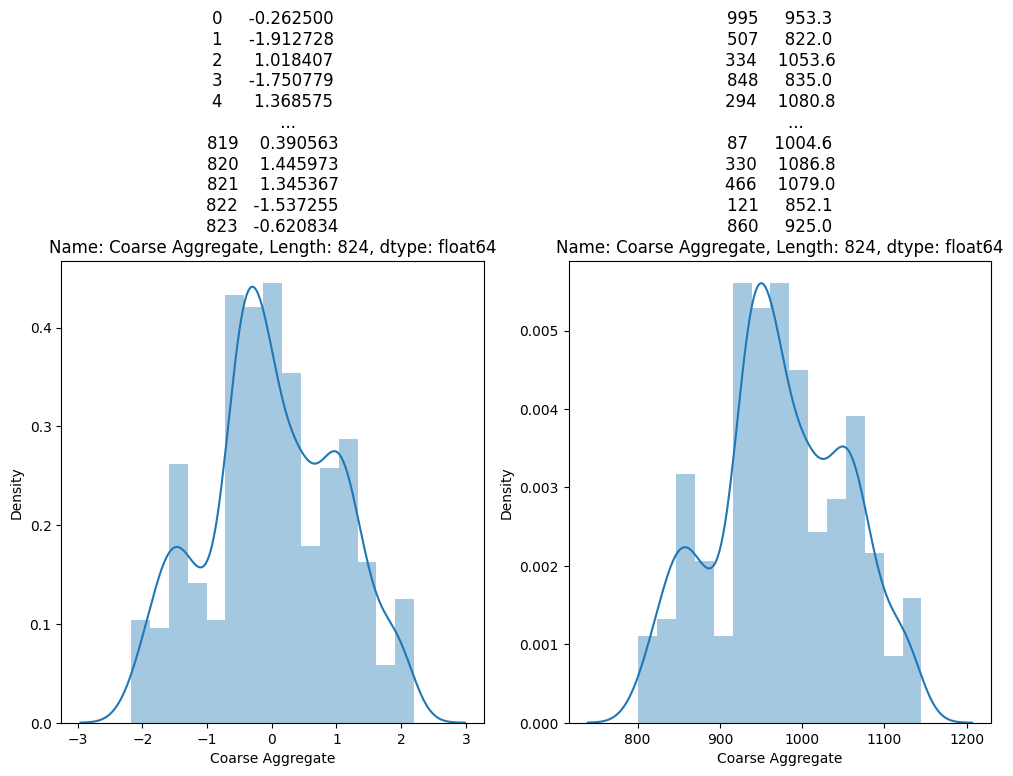

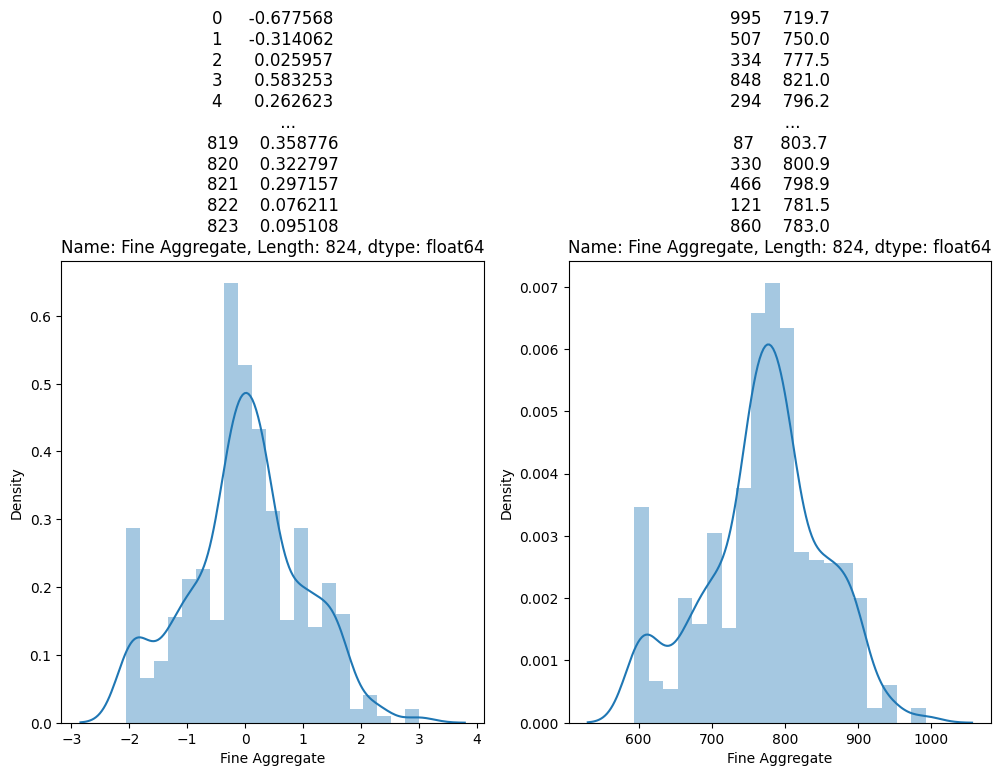

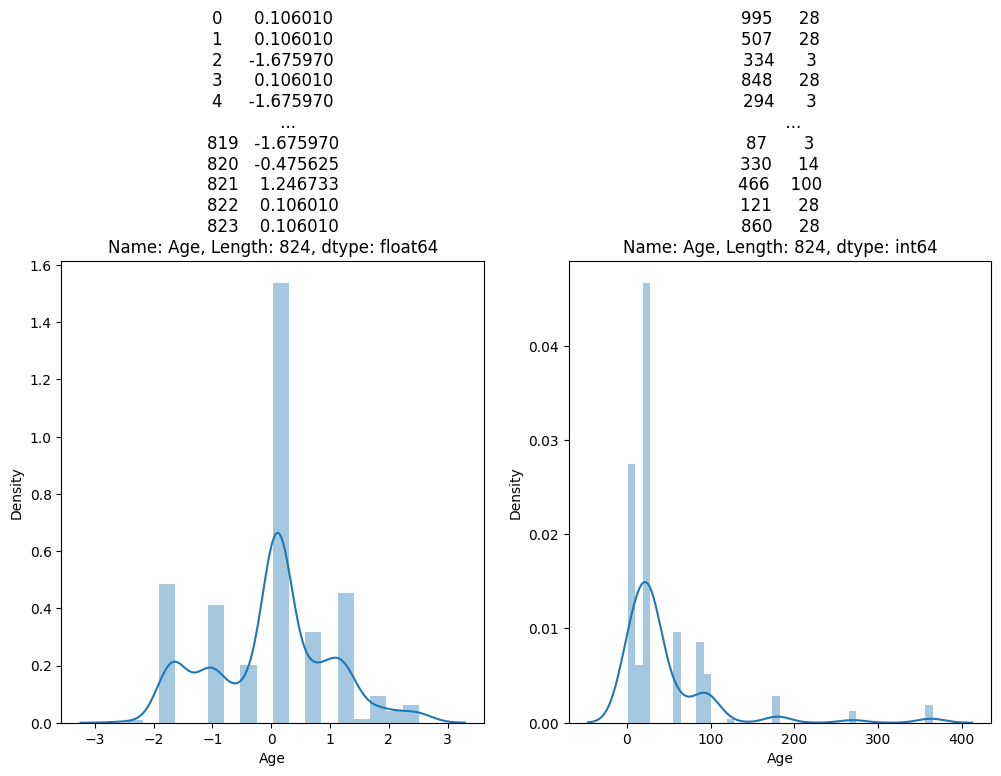

In [ ]:
X_train_trf=pd.DataFrame(X_train_trf,columns=X_train.columns)
for col in X_train_trf.columns:
  fig,(a1,a2)=plt.subplots(ncols=2,figsize=(12,6))
  sns.distplot(X_train_trf[col],ax=a1)
  a1.set_title(X_train_trf[col])
  sns.distplot(X_train[col],ax=a2)
  a2.set_title(X_train[col])
plt.show()

In [ ]:
pt=PowerTransformer()
X_train_trf1=pt.fit_transform(X_train+0.00000000001)
X_test_trf1=pt.transform(X_test+0.00000000001)
pd.DataFrame({'cols':X_train.columns,'yeo_jhonson_lambdas':pt.lambdas_})

,cols,yeo_jhonson_lambdas
0,Cement,0.174348
1,Blast Furnace Slag,0.015715
2,Fly Ash,-0.161447
3,Water,0.771307
4,Superplasticizer,0.253935
5,Coarse Aggregate,1.130050
6,Fine Aggregate,1.783100
7,Age,0.019885


In [ ]:
lr.fit(X_train_trf1,Y_train)
Y_pred3=lr.predict(X_test_trf1)
r2_score(Y_test,Y_pred3)

0.8161906506793951

In [ ]:
X_trf1=pt.fit_transform(X+0.00000000001)

In [ ]:
np.mean(cross_val_score(lr,X_trf,Y,scoring='r2'))

np.float64(0.6647104119595969)

/tmp/ipykernel_2111/709202772.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train_trf1[col],ax=a1)
/tmp/ipykernel_2111/709202772.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[col],ax=a2)
/tmp/ipykernel_2111/709202772.py:4: UserWarning: 

`distplot` is a deprecated function 

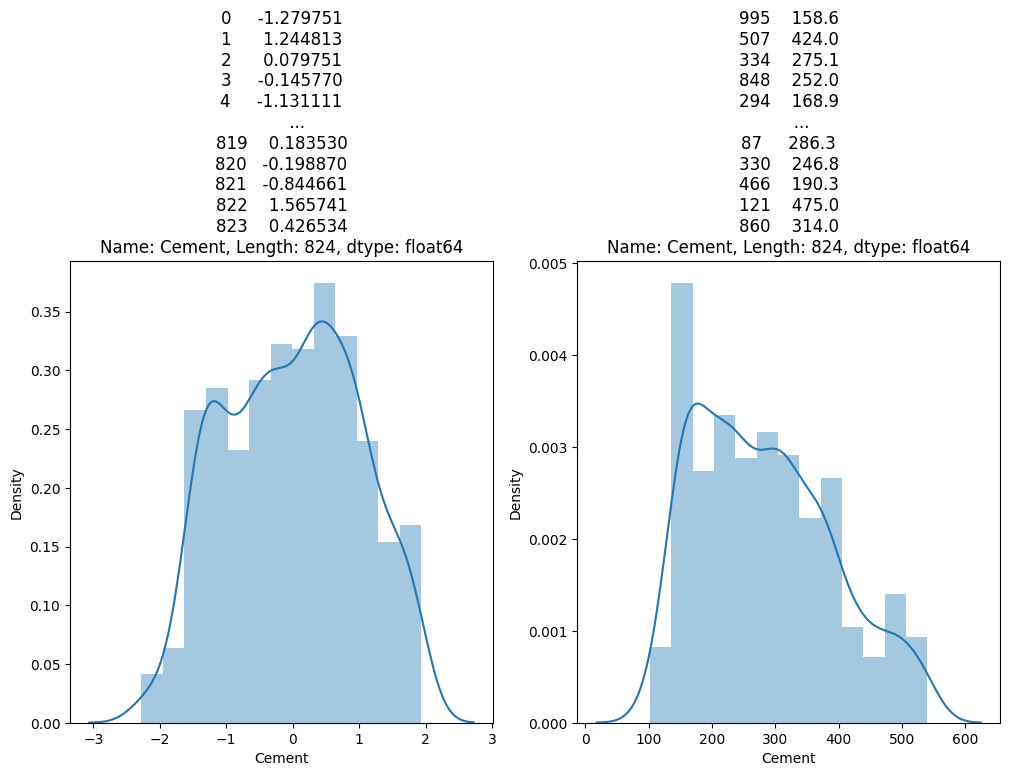

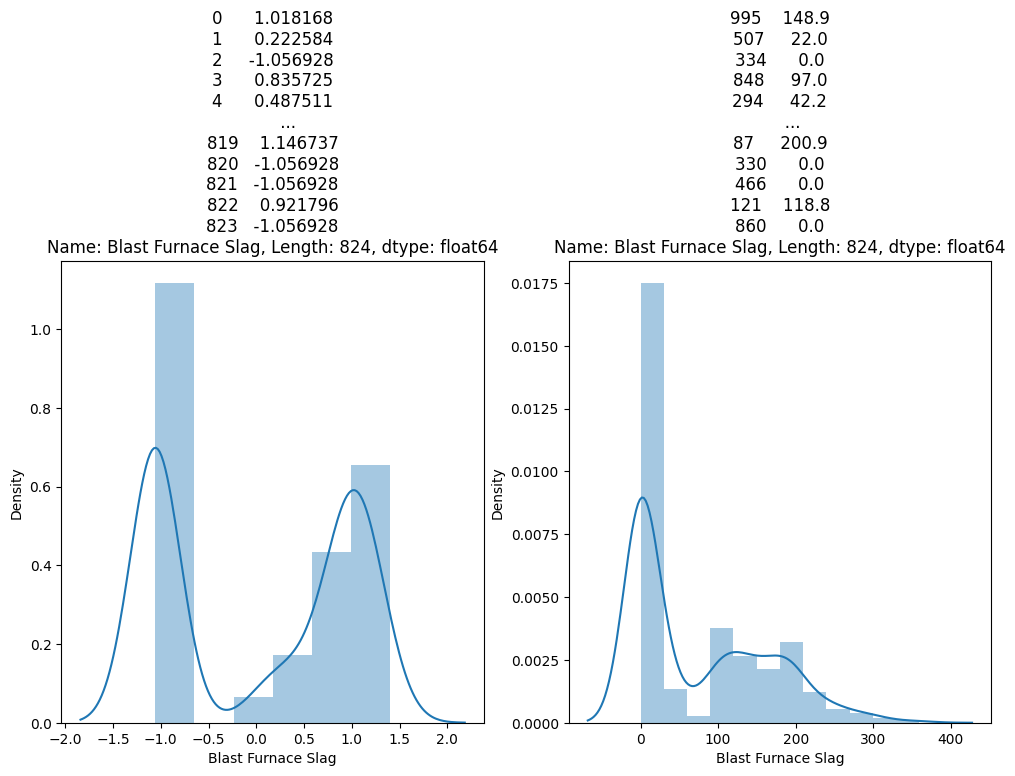

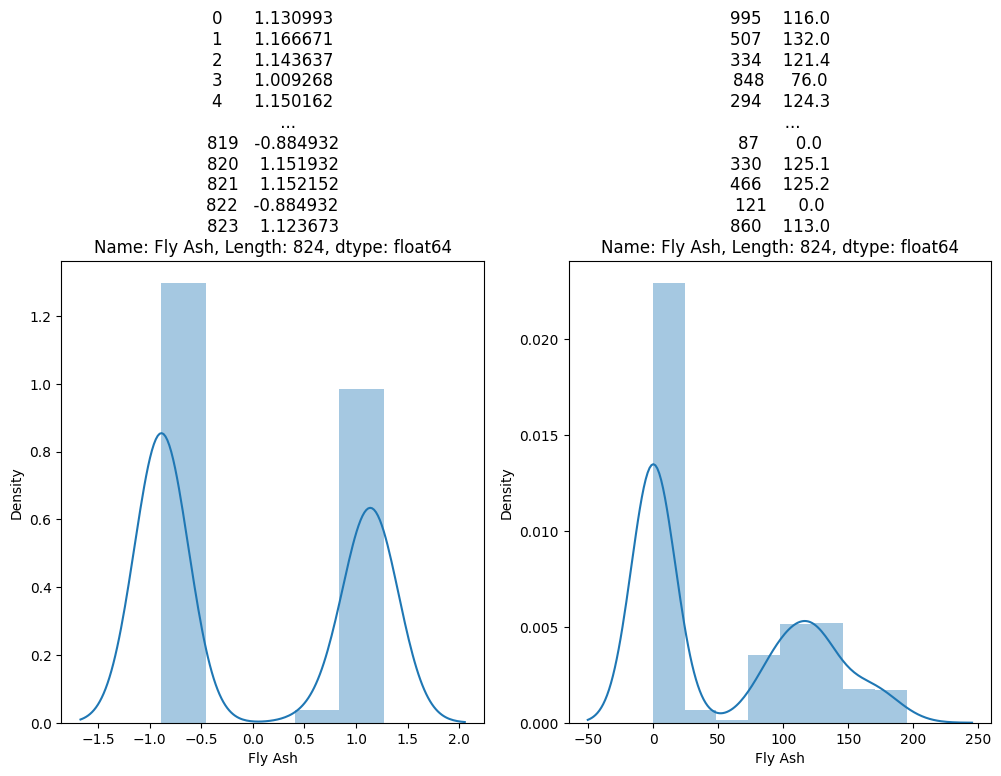

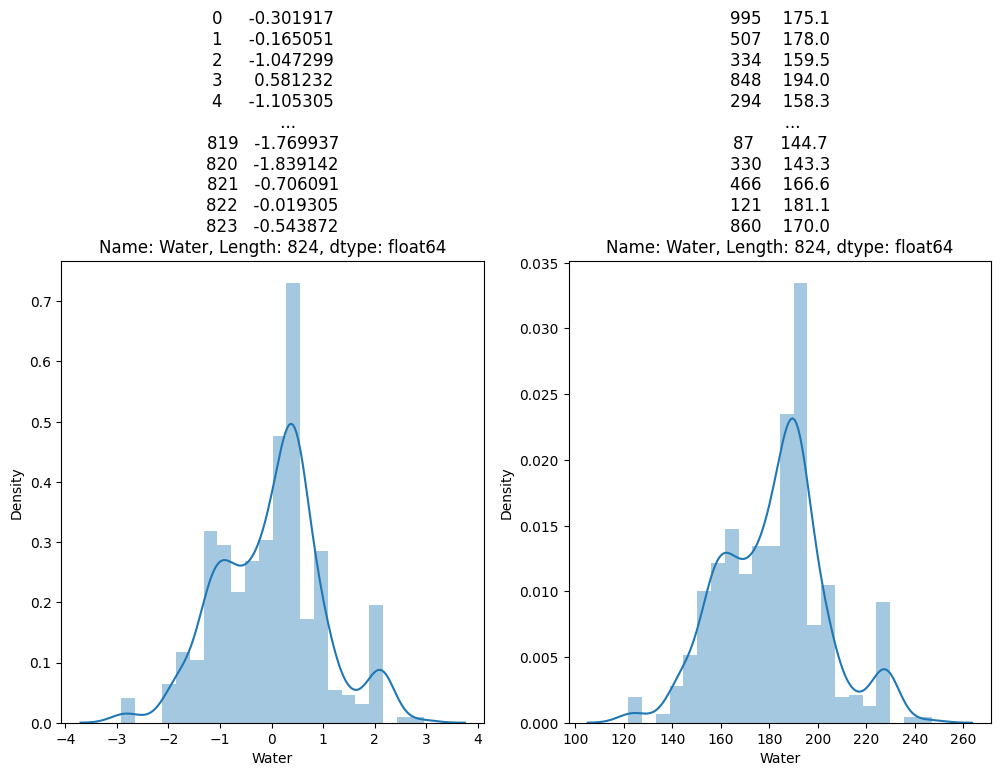

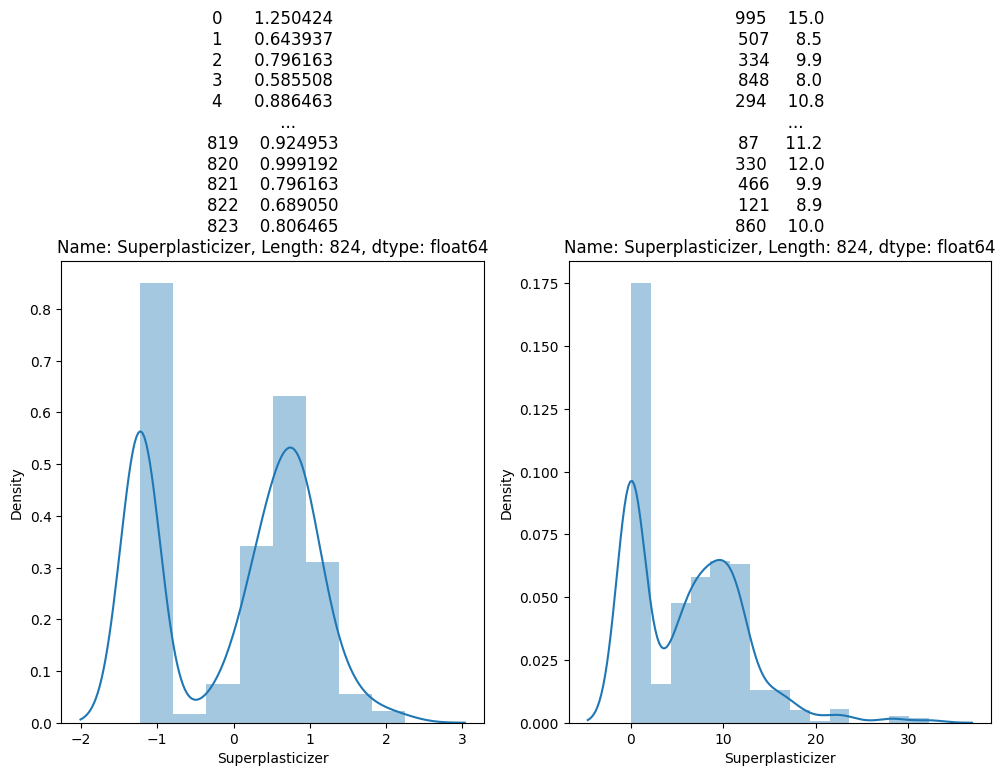

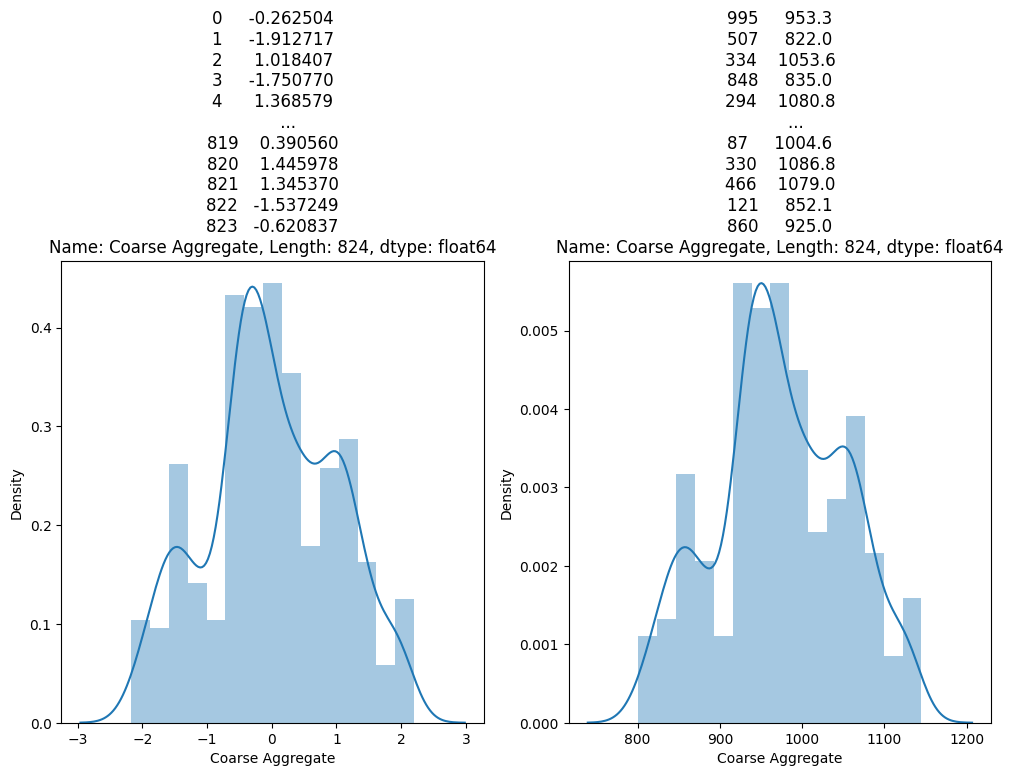

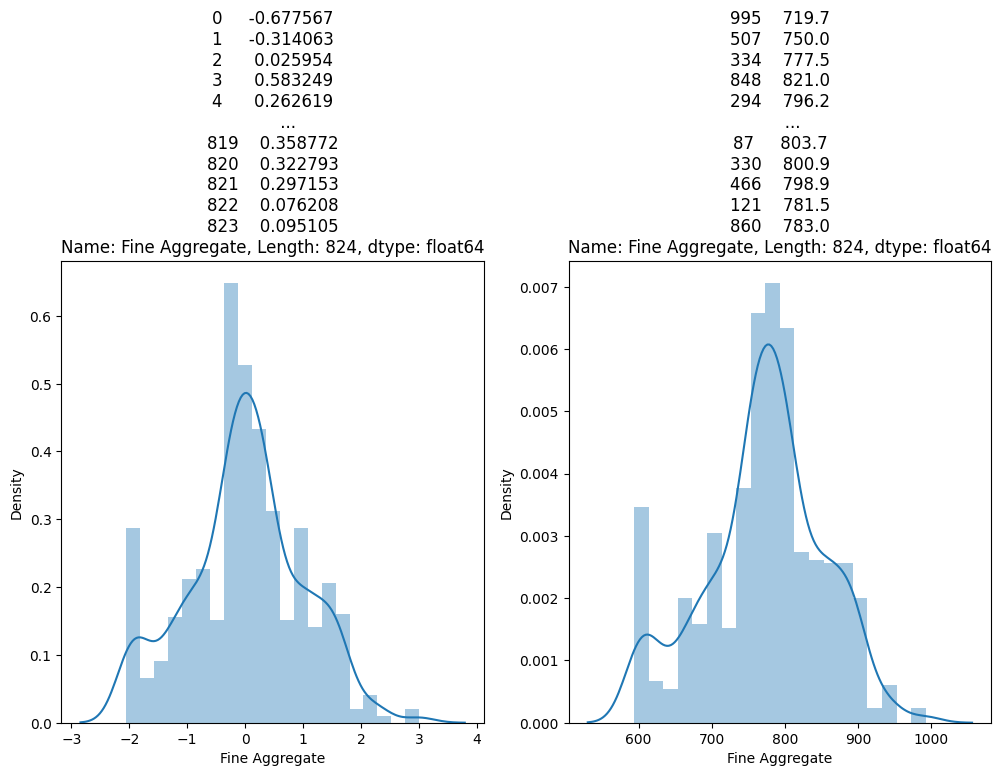

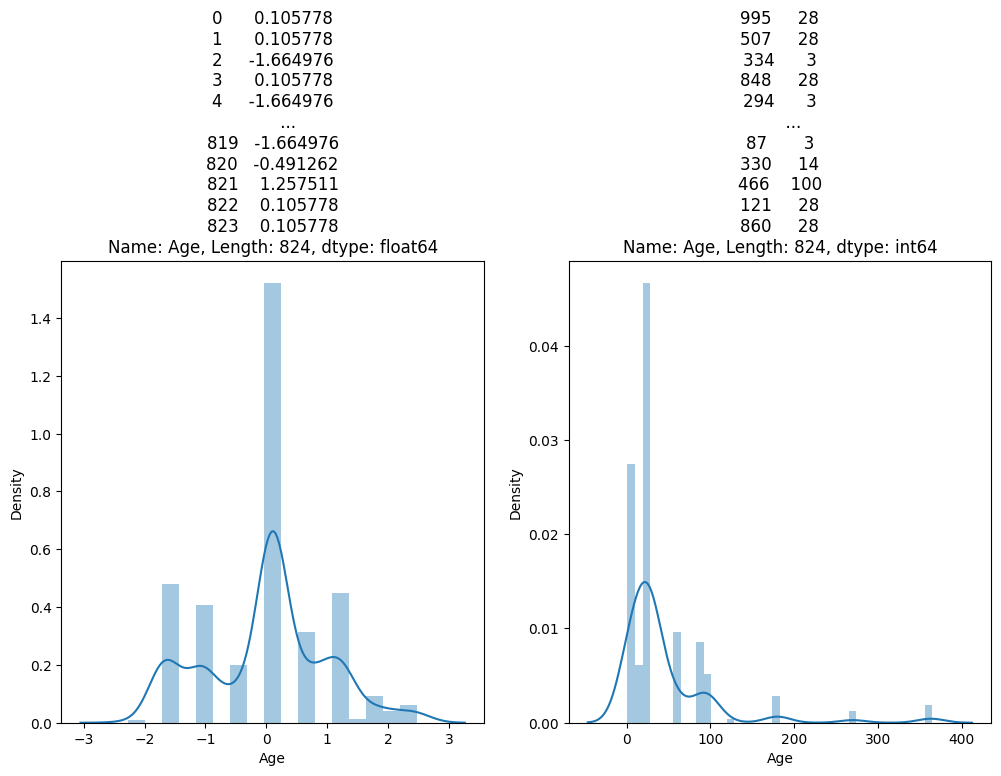

In [ ]:
X_train_trf1=pd.DataFrame(X_train_trf1,columns=X_train.columns)
for col in X_train_trf1.columns:
  fig,(a1,a2)=plt.subplots(ncols=2,figsize=(12,6))
  sns.distplot(X_train_trf1[col],ax=a1)
  a1.set_title(X_train_trf1[col])
  sns.distplot(X_train[col],ax=a2)
  a2.set_title(X_train[col])
plt.show()